In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

In [2]:
from cf_bench.config import SystemConfig
config = SystemConfig(backend="sklearn")
print(config)

=== System Config ===
backend                : sklearn
model_type             : classifier
target                 : hltprhc
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']
ordinal_features       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'dosprt']
continuous_features    : ['bmi']
ordinal_allowed_values : {'etfruit': [1, 2, 3, 4, 5, 6, 7], 'eatveg': [1, 2, 3, 4, 5, 6, 7], 'cgtsmok': [1, 2, 3, 4, 5, 6], 'alcfreq': [1, 2, 3, 4, 5, 6, 7], 'slprl': [1, 2, 3, 4], 'paccnois': [0, 1], 'dosprt': [0, 1, 2, 3, 4, 5, 6, 7]}
target_factor          : 0.5
features_to_vary       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


# Loading Data

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train a RandomforestClassifier for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [3]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [4]:
import pandas as pd

train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [5]:
train_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0
...,...,...,...,...,...,...,...,...,...
32878,4,4,6,6,1,0,22.679952,0,0
32879,1,2,4,7,1,0,23.875115,5,0
32880,2,2,6,2,1,0,23.629490,4,1
32881,4,4,6,7,2,0,29.700413,0,0


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [6]:
TARGET = config.target

In [7]:
import matplotlib.pyplot as plt

def plot_target_distribution(train_df, test_df, target_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Train
    train_df[target_col].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Train data-set")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="right")

    # Test
    test_df[target_col].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Test data-set")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="right")

    fig.suptitle(f"Distribution of {label} ({target_col})", fontsize=14)
    plt.tight_layout()
    plt.show()


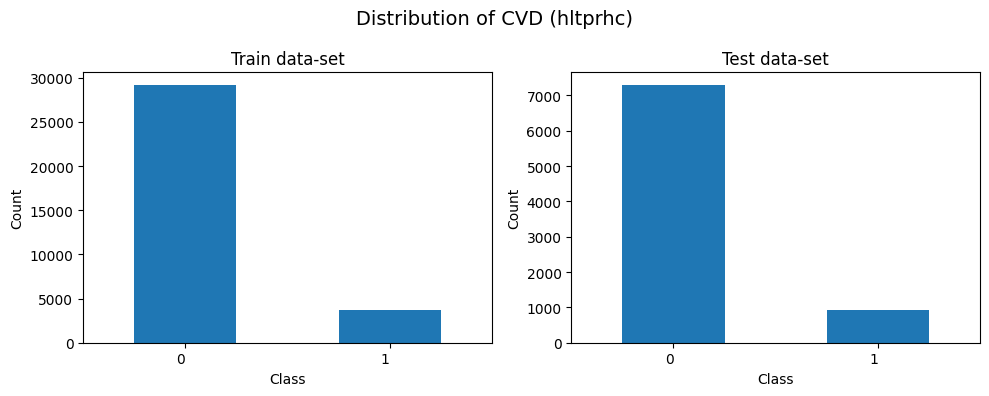

In [8]:
plot_target_distribution(train_df, test_df, TARGET, label="CVD")

# Loading old modell för later comparison

In [9]:
import joblib

current_hc_model = joblib.load(MODELS_DIR / "rf_hltprhc.pkl")

In [10]:
# -------------------------
X = config.feature_cols
# -------------------------

y_train = train_df[TARGET]
X_train = train_df[X]

y_true = test_df[TARGET]
X_test = test_df[X]

In [11]:
y_pred_current = current_hc_model.predict(X_test)

In [12]:
gridsearch_rf = pd.read_csv("rf_gridsearch_runs.csv")

In [13]:
gridsearch_rf = gridsearch_rf.sort_values(
    by=["mean_test_score", "std_test_score"],
    ascending=[False, True]
)

gridsearch_rf.head(10)

,run_id,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,rf__bootstrap,rf__class_weight,rf__max_features,rf__criterion,rf__n_estimators,rf__min_samples_split,rf__min_samples_leaf,rf__max_depth
21,2,23.800,0.851,0.689,0.026,0.547,0.550,0.560,0.549,0.008,2,True,NaN,sqrt,gini,599,3,1,15
20,2,17.965,0.421,0.484,0.031,0.545,0.551,0.564,0.549,0.009,1,True,NaN,sqrt,gini,470,6,1,15
22,2,13.846,0.519,0.318,0.016,0.546,0.546,0.564,0.549,0.009,3,True,NaN,sqrt,entropy,343,4,2,15
24,2,7.872,0.171,0.221,0.008,0.545,0.551,0.564,0.549,0.009,5,True,NaN,sqrt,gini,221,5,1,15
23,2,13.950,0.319,0.389,0.023,0.546,0.548,0.563,0.549,0.010,4,True,NaN,sqrt,gini,369,6,1,15
34,2,24.132,0.553,0.527,0.010,0.545,0.550,0.557,0.548,0.006,15,True,NaN,sqrt,entropy,588,6,2,15
26,2,22.201,0.691,0.499,0.012,0.547,0.546,0.559,0.548,0.007,7,True,NaN,sqrt,entropy,535,4,3,14
39,2,19.774,0.484,0.439,0.023,0.547,0.546,0.559,0.548,0.007,20,True,NaN,sqrt,entropy,528,3,3,14
0,1,5.805,0.272,0.150,0.008,0.544,0.550,0.560,0.548,0.008,1,True,NaN,sqrt,gini,164,6,1,14
25,2,19.490,0.222,0.478,0.010,0.547,0.549,0.560,0.548,0.008,6,True,NaN,sqrt,entropy,450,3,1,15


# train new modell based om best from gridsearch above + SMOTE

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [23]:
from sklearn.ensemble import RandomForestClassifier


best_gs_model = RandomForestClassifier(
    bootstrap=True,
    max_features="sqrt",
    criterion="gini",
    n_estimators=600,
    min_samples_split=3,
    min_samples_leaf=1,
    max_depth=15,
    class_weight=None, # no weights!
    random_state=42,
    n_jobs=-1
)

best_gs_model.fit(X_train_res, y_train_res)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [24]:
best_gs_pred = best_gs_model.predict(X_test)

# Compare

In [25]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

print("             === Current Modell ===")

print(classification_report(y_true, y_pred_current))
print()
print("Roc Score auc score: ", roc_auc_score(y_true, y_pred_current), "\n")

             === Current Modell ===
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      7287
           1       0.22      0.06      0.09       934

    accuracy                           0.87      8221
   macro avg       0.56      0.52      0.51      8221
weighted avg       0.81      0.87      0.83      8221


Roc Score auc score:  0.5165985949576098 



In [26]:
print("             === GS optimized Modell ===")

print(classification_report(y_true, best_gs_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_true, best_gs_pred), "\n")

             === GS optimized Modell ===
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      7287
           1       0.20      0.39      0.26       934

    accuracy                           0.75      8221
   macro avg       0.55      0.59      0.55      8221
weighted avg       0.83      0.75      0.78      8221


Roc Score auc score:  0.5918963664429542 



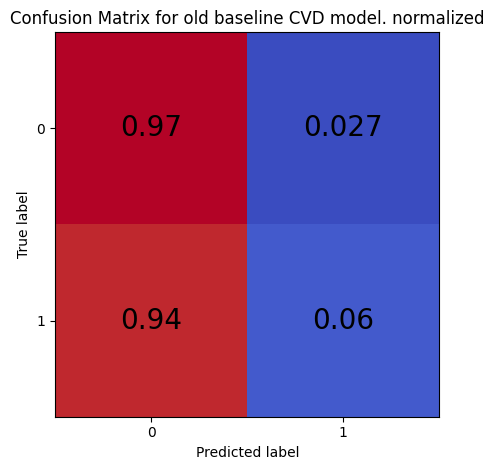

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_current,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")


plt.title("Confusion Matrix for old baseline CVD model. normalized")
plt.tight_layout()
plt.show()


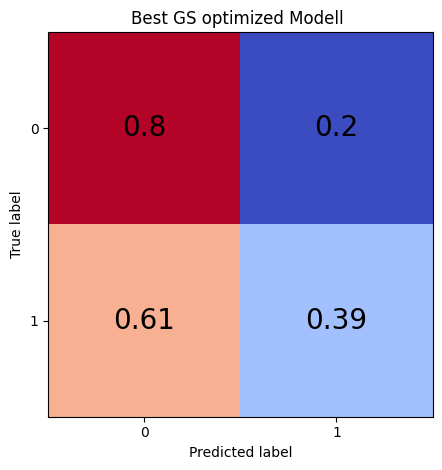

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    best_gs_pred,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")


plt.title("Best GS optimized Modell ")
plt.tight_layout()
plt.show()

In [29]:
joblib.dump(best_gs_model, MODELS_DIR / "rf_SMOTE_gridsearched.pkl")

['/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/models/rf_SMOTE_gridsearched.pkl']